In [69]:
!git clone https://github.com/karpathy/nanoGPT.git

fatal: destination path 'nanoGPT' already exists and is not an empty directory.


In [70]:
!pip install torch numpy transformers datasets tiktoken wandb tqdm

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import os
import sys

# Change working directory to the inner nanoGPT folder
base_path = os.getcwd()
nanoGPT_working_path = base_path + "/nanoGPT"

os.chdir(nanoGPT_working_path)

!python3 data/shakespeare_char/prepare.py

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


### Part A — Train a small GPT (20 pts)

### Config Changes
I reduced both n_layers and n_head by two and halved n_embed, I did this to make it easier to run locally, as I have a gpu that I used to train.

I also changed the number of iterations, this is self-explanatory.

In [2]:
'''
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
'''

import math
num_train_tokens = 1003854
batch_size = 64
block_size = 256

steps_per_epoch = math.floor(num_train_tokens / (batch_size * block_size))

print(f"Number of steps per epoch: {steps_per_epoch}")

print(f"Number of steps to run for 500 epochs: {500 * steps_per_epoch}")
print(f"Evaluate at steps: {5 * steps_per_epoch}, {50 * steps_per_epoch}, {500 * steps_per_epoch}")


Number of steps per epoch: 61
Number of steps to run for 500 epochs: 30500
Evaluate at steps: 305, 3050, 30500


Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 305 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 305  # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 4
n_head = 4
n_embd = 192
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 30500
lr_decay_iters = 250 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number o

/home/kyle/Documents/Code/Spring26/ProjAIML/Proj_AI_ML_HW4/nanoGPT/train.py:198: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 4.1908, val loss 4.1890
iter 0: loss 4.1914, time 10591.70ms, mfu -100.00%
step 305: train loss 2.3705, val loss 2.3894
saving checkpoint to out-shakespeare-char
iter 305: loss 2.4176, time 5989.45ms, mfu 0.01%
step 610: train loss 2.2596, val loss 2.2931
saving checkpoint to out-shakespeare-char
iter 610: loss 2.3356, time 3326.34ms, mfu 0.01%
step 915: train loss 2.1498, val loss 2.1968
saving checkpoint to out-shakespeare-char
iter 915: loss 2.2319, time 3649.26ms, mfu 0.01%
step 1220: train loss 2.0449, val loss 2.1140
saving checkpoint to out-shakespeare-char
iter 1220: loss 2.1631, time 3875.84ms, mfu 0.01%
step 1525: train loss 1.9504, val loss 2.0421
saving checkpoint to out-shakespeare-char
iter 1525: loss 2.0925, time 3944.85ms, mfu 0.01%
step 1830: train loss 1.8710, val loss 1.9889
saving checkpoint to out-shakespeare-char
iter 1830: loss 1.9795, time 3964.71ms, mfu 0.01%
step 2135: train loss 1.8123, val loss 1.9417
saving checkpoint to out-shakespeare-c

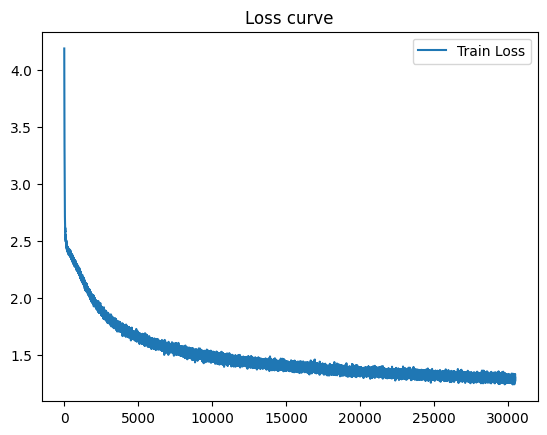

<Figure size 640x480 with 0 Axes>

In [73]:
%matplotlib inline
%run train.py config/train_shakespeare_char.py

In [74]:
with open(nanoGPT_working_path + "/out-shakespeare-char/epoch_5/train_val_loss.txt", "r") as f:
    content = f.read()

print("Train and Val loss for epoch 5:")
print(content)

Train and Val loss for epoch 5:
Train loss 2.3716, val loss 2.3902


### Samples from GPT @ Epoch 5

In [75]:
!python3 sample.py --out_dir=out-shakespeare-char/epoch_5 --num_samples=1 --max_new_tokens=1000

Overriding: out_dir = out-shakespeare-char/epoch_5
Overriding: num_samples = 1
Overriding: max_new_tokens = 1000
out-shakespeare-char/epoch_5/ckpt.pt
sample.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues rel

In [76]:
with open(nanoGPT_working_path + "/out-shakespeare-char/epoch_50/train_val_loss.txt", "r") as f:
    content = f.read()

print("Train and Val loss for epoch 50:")
print(content)

Train and Val loss for epoch 50:
Train loss 1.6777, val loss 1.8508


### Samples from GPT @ Epoch 50

In [77]:
!python3 sample.py --out_dir=out-shakespeare-char/epoch_50  --num_samples=1 --max_new_tokens=1000

Overriding: out_dir = out-shakespeare-char/epoch_50
Overriding: num_samples = 1
Overriding: max_new_tokens = 1000
out-shakespeare-char/epoch_50/ckpt.pt
sample.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues r

In [78]:
with open(nanoGPT_working_path + "/out-shakespeare-char/epoch_500/train_val_loss.txt", "r") as f:
    content = f.read()

print("Train and Val loss for epoch 500:")
print(content)

Train and Val loss for epoch 500:
Train loss 1.1657, val loss 1.4802


### Samples from GPT @ Epoch 500

In [79]:
!python3 sample.py --out_dir=out-shakespeare-char/epoch_500  --num_samples=1 --max_new_tokens=1000

Overriding: out_dir = out-shakespeare-char/epoch_500
Overriding: num_samples = 1
Overriding: max_new_tokens = 1000
out-shakespeare-char/epoch_500/ckpt.pt
sample.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues

### Part B — Train a PyTorch LSTM baseline (20 pts)

In [19]:
#Load the dataset and encode the dataset so it is usable by the model (I used this blog as a reference for help: https://agombert.github.io/AdvancedNLPClasses/chapter2/Session_2_2_Text_Generation_with_RNN/) (I was having issues with loading the dataset properly)
import torch
import torch.nn as nn
import torch.nn.functional as F
from copy import deepcopy
from datasets import load_dataset
import matplotlib.pyplot as plt

os.chdir(base_path)

tiny_data = load_dataset('karpathy/tiny_shakespeare', trust_remote_code=True)
train_texts = tiny_data['train']['text']  # list of strings

# Typically there's only 1 record with entire text.
all_text = " ".join(train_texts)
print(f"Dataset length in chars: {len(all_text)}")

# Build vocab
chars = sorted(list(set(all_text)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")

# char to int, int to char
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for ch,i in stoi.items() }

Dataset length in chars: 1003854
Vocabulary size: 65


In [20]:
#set up the batch sampling
block_size = 256
batch_size = 64
device = "cuda" if torch.cuda.is_available() else "cpu"

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [21]:
# create the LSTM model
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits

#init model
model = CharLSTM(vocab_size).to(device)
#set optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 5 loss: 2.3081
Epoch 50 loss 1.3586
Epoch 500 loss 0.5793


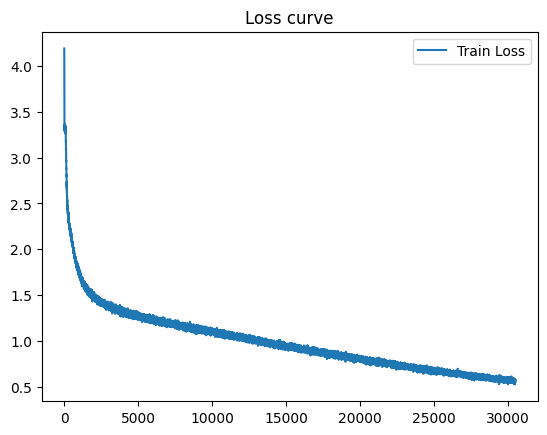

In [22]:
#keep same parameters from nanoGPT
max_iters = 30500
eval_interval = 305

train_loss = []

epoch_5_model = None
epoch_50_model = None

for step in range(max_iters+1):
    xb, yb = get_batch("train")
    logits = model(xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1))

    train_loss.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step == 305:
        print(f"Epoch 5 loss: {loss.item():.4f}")
        epoch_5_model = deepcopy(model)
    if step == 3050:
        print(f"Epoch 50 loss {loss.item():.4f}")
        epoch_50_model = deepcopy(model)
    if step == 30500:
        print(f"Epoch 500 loss {loss.item():.4f}")

plt.plot(train_loss, label='Train Loss')
plt.title("Loss curve")
plt.legend()
plt.show()

In [23]:
@torch.no_grad()
def generate(model, start="\n", length=1000):
    model.eval()
    x = torch.tensor([[stoi[start]]], device=device)
    out = start

    for _ in range(length):
        logits = model(x)
        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_id = torch.multinomial(probs, 1)
        x = torch.cat([x, next_id], dim=1)
        out += itos[next_id.item()]

    return out

### Sample from LSTM @ epoch 5

In [24]:
print(generate(epoch_5_model))


Fhoy, pua hyaue,
Hurve viets goy loake.
Setae pae liavoivy and Sosverdlns Relad,
So mumisiel, I Ceauoe there nate thoy peer nalr hootd brydints, py to miads? ue beny hyane hoy peae he hiue os yirn
Atlh the sothst; the tinlsn yiy. 
Uenreddiood to anll, rotes as mutvrndeeblluelglrmcy. Lore-Noed,
Thele woa, sot my mied
Lo the whautgie afebeJ for the hoer tegciah not seitdlovage, the Rortes on, pame shiet cirereee as, ceflaor. Jy Mecels, tiy ufaoah the: oys uftfan,
Wotlocy day Is of I cire coevtesmend titded to blel.
Shroce, onnet undind andolp. I
Te hrandss.
beweems dlu the, thie hes werenln on moroank tarngiuneeen:-coror to it basts lranrelide? Auts unmotde't
If Herrece elepmenals
Vy,shes sorilietdend
Areagke.,
Sot hale sot fimkangitle het the ceobrenoown: sonths, socety
Shet shitted
Whway dereres hare to alintch.
Feaesrmidqeinh anoe a Igomdee hoid woe. 
he at thet bulrsn, wheud:

PEROUE :
Wordems woudd yiyploge sot; chakegt-To derurretle,
Yoar thi'd metdtieln to proress bere; of bassde

### Sample from LSTM @ epoch 50

In [25]:
print(generate(epoch_50_model))


Shelty to my dear bear childs, therefore
Wurlsn ignhighs not not tumps to him. Should thou know
Hath resaes? the duke right and gain yet
To get a has how yield them with him.

KATHERLAN:
I would my commend with-bloin
Thou says I have but twenty stands, too broudly and help me,
Find there Claudio'd o's bosom, pright and Henry:'
God son why for me and pass of right.

QUEEN MARGARET:
Her you, belolf no alone interning learn of your
ovants own eog of death:
Have it bow our request with this son.
But or you well?
Never not is her matter:-may I when they sures
That in what will fight: I think your brother.
May that then, I pale; they hood's mark; threek.

FLORIZEL:
Shall thou sit,
And more no imposbeg, had I her made 'of have;
I yet still grie's over!
O, weongering blemisiussion wised Swal.

MONTAGUE:
Wellmuty is all, brother, to the good will teeth
All did bly this morlardege booing remom,
Since you will take that one geilt and fine;
But in not as toy, if you were never blonder conclaid.



### Sample from LSTM @ epoch 500

In [26]:
print(generate(model))


DUKE VINCENTIO:
Boing his mother;
His windows of my Lord of Norfolk.

LUCIO:
With he, he's good lose.
And, if you had, a head on me; and go with you,
And what he tortuphes daylixtges in this ausay
whick no wine only bruth, answer his time,
It came by night, unjustice, I dare be,
And thou a life of my sweet nurse,
And as substall'd us wear'st; but over-place,
To fleen right unto the die of mine eyes,
Like taster, that he reason lasting are,
There thy heavens drop of this sun shame.

BENVOLIO:
Tut, you say my roare to her heart with secrehes
Do live: whence was greatness might have woman,
With grief, being altogether racking them.

KING RICHARD II:
Mine eyes Tarquiding two, I know, my lord.

KING RICHARD III:
Say, these issue upon him.

BRUTUS:
You know the very weeds cannot live.

ISABELLA:
Even as ever has been back'd in years,
And make my tongue can call again with usurpous
of what he cowers all at twing then stay.

QUEEN MARGARET:
Ah, will not mistrust us, in galler-place
Your thron

### Part C — Comparison writeup (10 pts)
#### Briefly compare GPT vs LSTM at each checkpoint (5 $\rightarrow$ 50 $\rightarrow$ 500): coherence, formatting, repetition loops, and character/word structure.

#### Epoch 5

5 epochs of training is not very much so I would expect the models to not be very good, and that is what I observed; however there are some differences in the outputs of the two models. Both of the models are completely incoherent and do not output words at all, however the GPT model seems to follow the structure of the original text much better than the LSTM model. The LSTm model does display some formatting properties of the original text but significantly less than the GPT model.

#### Epoch 50

50 epochs is 10x the last checkpoint, so I expect a better output, but I don't expect it to be perfect. The GPT model is able to output much better structure than the LSTM model but they both display properties of the original text. In the case of the GPT model it outputs much more properly spelled words, but it still outputs words spelled wrong, and in some cases gibberish. I noticed it will(l) add and extra l to the word will, and it does it quite frequently. As for the LSTM model is outputs some correct words with good formatting, but still outputs alot of gibberish.

#### Epoch 500
500 epochs is the maximum training epochs I ran so this is the final model, so I expect the bets output from these models compared to the last. This is the result that I observed, with some caveats. The GPT model performed very well, it formats the text very well and looks like the original text, and it spells words correctly, however the text does not necessarily mean anything. While the text is readable and flows well, the words don't really mean much, this is probably because the starting prompt is a newline character, If it was given a better starting prompt it could probably produce a more meaningful output. As for the LSTM model its output formatting it very similar to the original text, but compared to the GPT model its passages are much longer. Also, the LSTM model still either spells words wrong or makes up its own words in some cases, which leads to some inconsistent passages in some cases.

Overall at each checkpoint the GPT model outperforms the LSTM model, which is an expected result as the GPT mode is designed to be used with text based input.

#### Explain one significant differences between the models’ outputs and relate them to architecture (attention vs recurrence) or training behavior (overfitting/underfitting, optimization stability).

In the case of the GPT model, it utilizes an attention mechanism. This attention mechanism allows for the model to "pay attention" to relevant inputs, especially if the input is long, it can use the information it has been given more effectively. Compared to the LSTM model, the GPT model has a much larger "context window" which allows it to produce more coherent outputs and can structure the text much better than the LSTM model as it can "remember" earlier inputs. This larger context allows the model to continue outputting relevant information compared to the LSTM model, this can explain why the formatting and coherence is better for the GPT model, as it has more information available to estimate the next best character.